  
  # Notebook 04 — XGBoost
  **Regression** → Predict WQI
  **Classification** → Predict Water Quality Category

  ### Why XGBoost?
  - Stands for **Extreme Gradient Boosting**
  - Unlike Bagging/Random Forest (trees built independently in parallel),
    XGBoost builds trees **sequentially** — each tree corrects the errors of the previous one
  - Uses **Gradient Descent** to minimize errors at each step
  - One of the most powerful algorithms for structured/tabular data
  - Wins most Kaggle competitions on tabular datasets

  ### Bagging vs Boosting:
  | | Bagging / Random Forest | XGBoost (Boosting) |
  |---|---|---|
  | Trees built | Independently (parallel) | Sequentially |
  | Each tree focuses on | Random subset | Previous tree's mistakes |
  | Combines by | Average / Vote | Weighted sum |
  | Overfitting risk | Low | Medium (needs tuning) |
  | Speed | Fast | Slower but more accurate |

In [2]:
#%pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pickle
import numpy as np
import pandas as pd                                             
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)


In [4]:
#(Load Data)

with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("Classes   :", list(le.classes_))



Train size: (15223, 30)
Test  size: (3806, 30)
Classes   : ['Excellent', 'Good', 'Poor', 'Unsuitable for Drinking', 'Very Poor yet Drinkable']


## How XGBoost Works — Intuition

Step 1: Build a small tree → makes predictions → calculates residual errors
Step 2: Next tree learns to predict those residual errors
Step 3: Add predictions of both trees together
Step 4: Repeat N times (n_estimators)

Example:
Actual WQI    = 300
Tree 1 predicts = 250  → error = 50
Tree 2 predicts =  40  → error = 10
Tree 3 predicts =   8  → error =  2
...
Final = 250 + 40 + 8 + ... = ~300 

Each tree patches the mistakes of all previous trees.

In [5]:
#(Train XGBoost Regressor)

xgb_reg = XGBRegressor(
  n_estimators=100,
  learning_rate=0.1,     # how much each tree contributes
  max_depth=6,           # depth of each tree
  subsample=0.8,         # fraction of data per tree
  colsample_bytree=0.8,  # fraction of features per tree
  random_state=42,
  verbosity=0
)
xgb_reg.fit(X_train, y_reg_train)                               

y_pred_train = xgb_reg.predict(X_train)
y_pred_test  = xgb_reg.predict(X_test)

r2_train = r2_score(y_reg_train, y_pred_train)                  
r2_test  = r2_score(y_reg_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
mae      = mean_absolute_error(y_reg_test, y_pred_test)

print("=== XGBoost Regressor ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")



=== XGBoost Regressor ===
R² Train : 0.9995
R² Test  : 0.9538
RMSE     : 69.73
MAE      : 8.19


### Learning Rate vs n_estimators — Key Tradeoff
  - **Low learning rate** → each tree contributes less → need MORE trees → slower but better
  - **High learning rate** → each tree contributes more → need FEWER trees → faster but risks overfitting

  Rule of thumb: lower learning_rate + higher n_estimators = better generalization



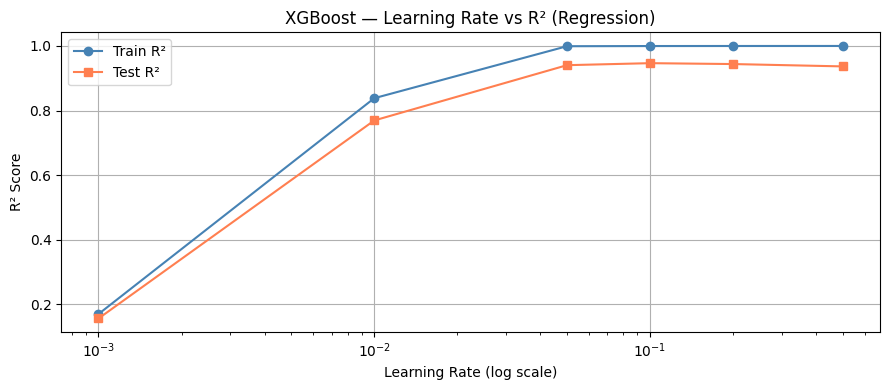

In [6]:
#(Learning Rate Effect)                            

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
train_scores, test_scores = [], []

for lr in learning_rates:
  m = XGBRegressor(
      n_estimators=100,
      learning_rate=lr,
      max_depth=6,
      random_state=42,                                        
      verbosity=0
  )
  m.fit(X_train, y_reg_train)
  train_scores.append(r2_score(y_reg_train, m.predict(X_train)))
  test_scores.append(r2_score(y_reg_test,   m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(learning_rates, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(learning_rates, test_scores,  marker='s', label='Test R²',  color='coral')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('R² Score')
plt.title('XGBoost — Learning Rate vs R² (Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


  ## Part 2 — XGBoost Classifier (Predict Water Quality)

In [8]:
#(Train XGBoost Classifier)

xgb_clf = XGBClassifier(
  n_estimators=100,
  learning_rate=0.1,
  max_depth=6,
  subsample=0.8,                                              
  colsample_bytree=0.8,
  random_state=42,
  verbosity=0,
  eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_clf_train)

y_clf_pred_train = xgb_clf.predict(X_train)
y_clf_pred_test  = xgb_clf.predict(X_test)

acc_train = accuracy_score(y_clf_train, y_clf_pred_train)       
acc_test  = accuracy_score(y_clf_test,  y_clf_pred_test)
f1_test   = f1_score(y_clf_test, y_clf_pred_test, average='weighted')

print("=== XGBoost Classifier ===")
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")                       
print(f"F1 Score Test  : {f1_test:.4f}")

=== XGBoost Classifier ===
Accuracy Train : 0.9997
Accuracy Test  : 0.9769
F1 Score Test  : 0.9769


In [9]:
#(Early Stopping — Prevent Overfitting)

xgb_clf_es = XGBClassifier(
  n_estimators=500,       # set high — early stopping will find the best
  learning_rate=0.05,
  max_depth=6,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42,
  verbosity=0,                                                
  eval_metric='mlogloss',
  early_stopping_rounds=20  # stop if no improvement for 20 rounds
)

xgb_clf_es.fit(
  X_train, y_clf_train,                                       
  eval_set=[(X_test, y_clf_test)],
  verbose=False
)

best_round = xgb_clf_es.best_iteration                          
y_pred_es  = xgb_clf_es.predict(X_test)
acc_es     = accuracy_score(y_clf_test, y_pred_es)
f1_es      = f1_score(y_clf_test, y_pred_es, average='weighted')

print(f"Best round (early stopping) : {best_round}")
print(f"Accuracy Test               : {acc_es:.4f}")
print(f"F1 Score Test               : {f1_es:.4f}")

Best round (early stopping) : 424
Accuracy Test               : 0.9779
F1 Score Test               : 0.9779


In [11]:
#(Classification Report)

print("=== XGBoost Classification Report ===")
print(classification_report(
  y_clf_test,
  y_pred_es,
  target_names=le.classes_
))


=== XGBoost Classification Report ===
                         precision    recall  f1-score   support

              Excellent       0.96      0.99      0.97       136
                   Good       0.97      0.96      0.96       317
                   Poor       0.98      0.98      0.98      1066
Unsuitable for Drinking       0.99      0.99      0.99      1370
Very Poor yet Drinkable       0.97      0.97      0.97       917

               accuracy                           0.98      3806
              macro avg       0.97      0.98      0.97      3806
           weighted avg       0.98      0.98      0.98      3806



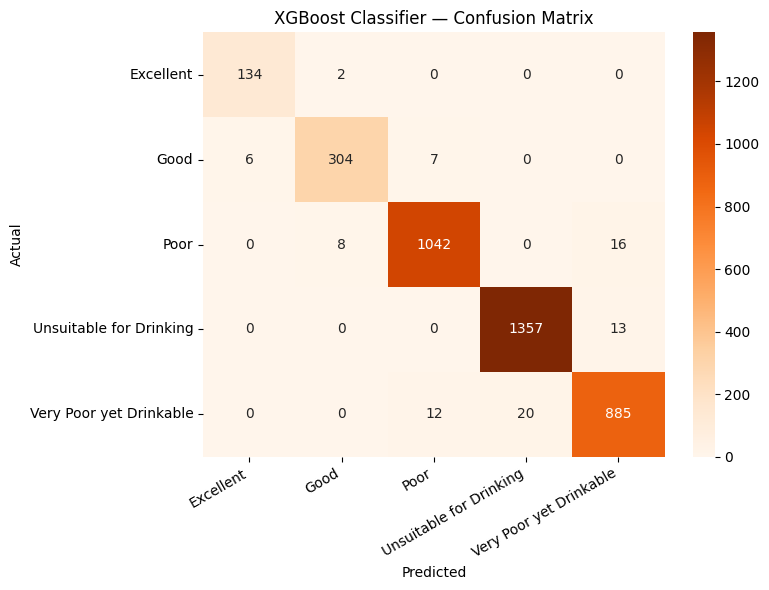

In [13]:
#(Confusion Matrix)

cm = confusion_matrix(y_clf_test, y_pred_es)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title('XGBoost Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')                                         
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


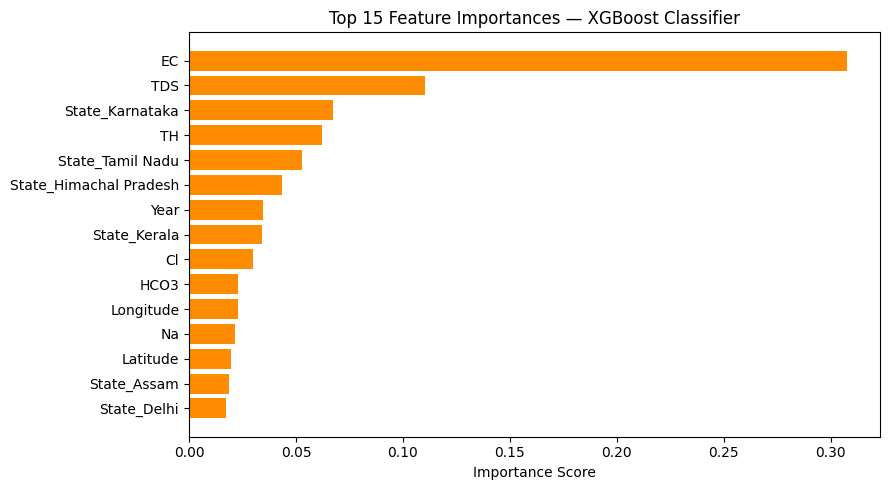

In [14]:
#(Feature Importance)                             

importances = xgb_clf_es.feature_importances_
feat_imp = pd.DataFrame({
  'Feature': feature_names,
  'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='darkorange')
plt.title('Top 15 Feature Importances — XGBoost Classifier')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [17]:
# Load results from previous notebooks
with open('results_01_linear_logistic.pkl', 'rb') as f:
  res_01 = pickle.load(f)

with open('results_02_decision_tree.pkl', 'rb') as f:
  res_02 = pickle.load(f)

with open('results_03_random_forest.pkl', 'rb') as f:
  res_03 = pickle.load(f)

summary = pd.DataFrame([
  {
      'Model': 'Logistic Regression',            
      'Task': 'Classification',
      'Acc Train': round(res_01['Logistic Regression']['acc_train'], 4),
      'Acc Test':  round(res_01['Logistic Regression']['acc_test'],  4),
      'F1 Test':   round(res_01['Logistic Regression']['f1_test'],   4)
  },
  {
      'Model': 'Decision Tree',
      'Task': 'Classification',                  
      'Acc Train': round(res_02['Decision Tree Classification']['acc_test'], 4),
      'Acc Test':  round(res_02['Decision Tree Classification']['acc_test'], 4),
      'F1 Test':   round(res_02['Decision Tree Classification']['f1_test'],  4)
  },
  {
      'Model': 'Random Forest',
      'Task': 'Classification',                  
      'Acc Train': round(res_03['Random Forest Classification']['acc_train'], 4),
      'Acc Test':  round(res_03['Random Forest Classification']['acc_test'],  4),
      'F1 Test':   round(res_03['Random Forest Classification']['f1_test'],   4)
  },
  {
      'Model': 'XGBoost (early stopping)',
      'Task': 'Classification',                  
      'Acc Train': round(acc_train, 4),
      'Acc Test':  round(acc_es,    4),
      'F1 Test':   round(f1_es,     4)
  }
])

summary


,Model,Task,Acc Train,Acc Test,F1 Test
0,Logistic Regression,Classification,0.9631,0.9611,0.9609
1,Decision Tree,Classification,0.9569,0.9569,0.9570
2,Random Forest,Classification,1.0000,0.9630,0.9629
3,XGBoost (early stopping),Classification,0.9997,0.9779,0.9779


In [18]:
#(Save Results)

results = {
  'XGBoost Regression': {
      'r2_train': r2_train,
      'r2_test':  r2_test,
      'rmse':     rmse                                        
  },
  'XGBoost Classification': {
      'acc_train': acc_train,
      'acc_test':  acc_es,
      'f1_test':   f1_es,
      'best_round': best_round                                
  }
}

with open('results_04_xgboost.pkl', 'wb') as f:
  pickle.dump(results, f)                                     

print("Saved. Move on to 05_KNN.ipynb")



Saved. Move on to 05_KNN.ipynb
